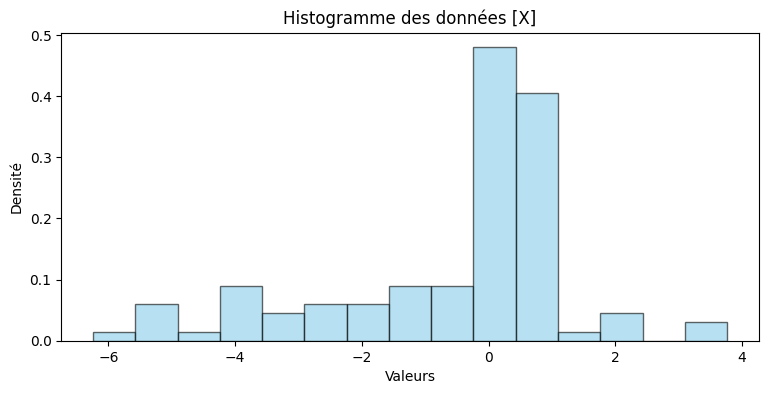

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

gaus = np.random.normal(-1.5, 2, 50)
unif = np.random.uniform(0,1,50)
(gaus,unif)

X = np.concatenate([gaus, unif])
X

plt.figure(figsize=(9,4))
plt.hist(X, bins=15, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.title("Histogramme des données [X]")
plt.xlabel("Valeurs")
plt.ylabel("Densité")
plt.show()

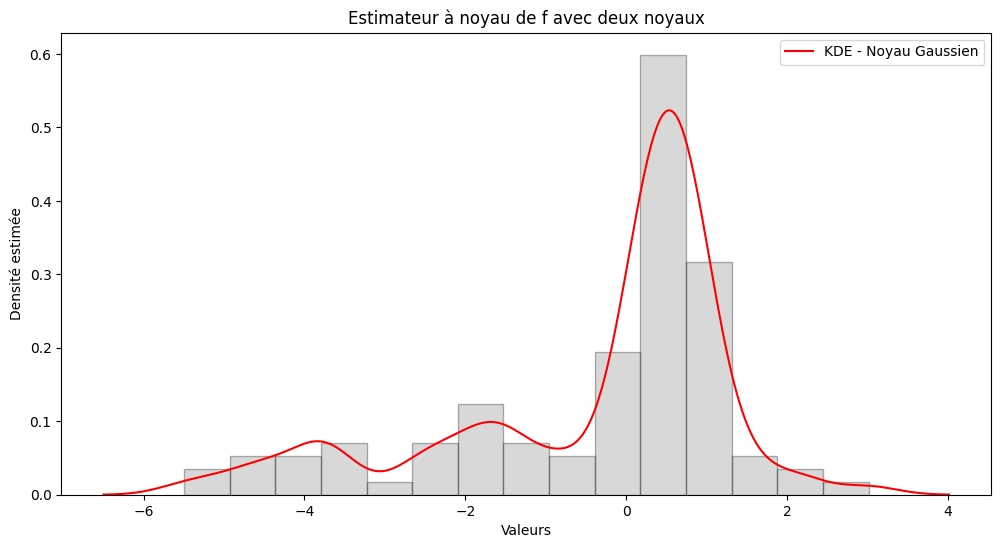

In [ ]:
# 2b. Estimation par noyau (KDE)
x_eval = np.linspace(min(X)-1, max(X)+1, 500)

# --- Noyau Gaussien
kde_gauss = gaussian_kde(X, bw_method=0.2)  # Bande passante ajustée à la main
plt.figure(figsize=(12,6))
plt.plot(x_eval, kde_gauss(x_eval), label="KDE - Noyau Gaussien", color="red")

plt.hist(X, bins=15, density=True, alpha=0.3, color='grey', edgecolor='black')
plt.title("Estimateur à noyau de f avec deux noyaux")
plt.xlabel("Valeurs")
plt.ylabel("Densité estimée")
plt.legend()
plt.show()

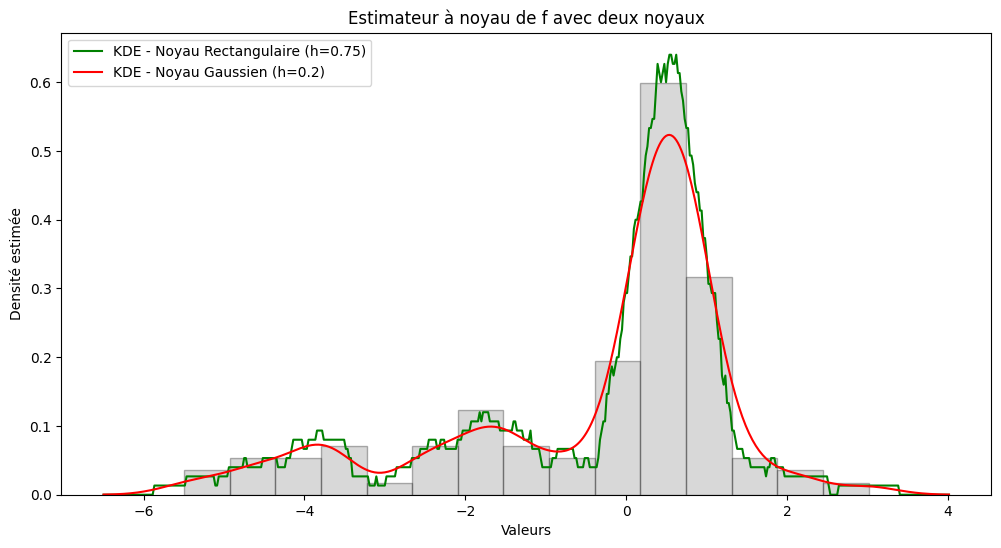

In [ ]:
# --- Noyau Uniforme (Tophat) implémenté à la main
def kde_tophat(data, x_points, bandwidth):
    n = len(data)
    densities = []
    for x in x_points:
        # Compte combien de points tombent dans la fenêtre
        count = np.sum(np.abs((x - data) / bandwidth) <= 0.5)
        dens = count / (n * bandwidth)
        densities.append(dens)
    return np.array(densities)

dens_tophat = kde_tophat(X, x_eval, bandwidth=0.75)
plt.figure(figsize=(12,6))
plt.plot(x_eval, dens_tophat, label="KDE - Noyau Rectangulaire (h=0.75)", color="green")
plt.plot(x_eval, kde_gauss(x_eval), label="KDE - Noyau Gaussien (h=0.2)", color="red")

# Ajout de l'histogramme
plt.hist(X, bins=15, density=True, alpha=0.3, color='grey', edgecolor='black')
plt.title("Estimateur à noyau de f avec deux noyaux")
plt.xlabel("Valeurs")
plt.ylabel("Densité estimée")
plt.legend()
plt.show()

In [ ]:
# 2c. Validation croisée manuelle pour choisir la meilleure bande passante
def leave_one_out_loglik(data, bandwidth, kernel="gaussian"):
    n = len(data)
    loglik = 0.0
    for i in range(n):
        # on laisse de côté le i-ème point
        train = np.delete(data, i)
        if kernel == "gaussian":
            kde = gaussian_kde(train, bw_method=bandwidth)
            loglik += np.log(kde(data[i]))
        elif kernel == "rectangulaire":
            dens = kde_tophat(train, [data[i]], bandwidth)[0]
            loglik += np.log(dens + 1e-12)  # évite log(0)
    return loglik

bandwidths = np.linspace(0.1, 1.0, 30)
scores = [leave_one_out_loglik(X, bw, kernel="gaussian") for bw in bandwidths]
best_bw = bandwidths[np.argmax(scores)]
scores1 = [leave_one_out_loglik(X, bw, kernel="rectangulaire") for bw in bandwidths]
best_bw1 = bandwidths[np.argmax(scores1)]

In [ ]:
# Estimation finale avec la meilleure bande passante
kde_optimal = gaussian_kde(X, bw_method=best_bw)
dens_optimal = kde_optimal(x_eval)

dens_optimal1 = kde_tophat(X, x_eval, bandwidth=best_bw1)

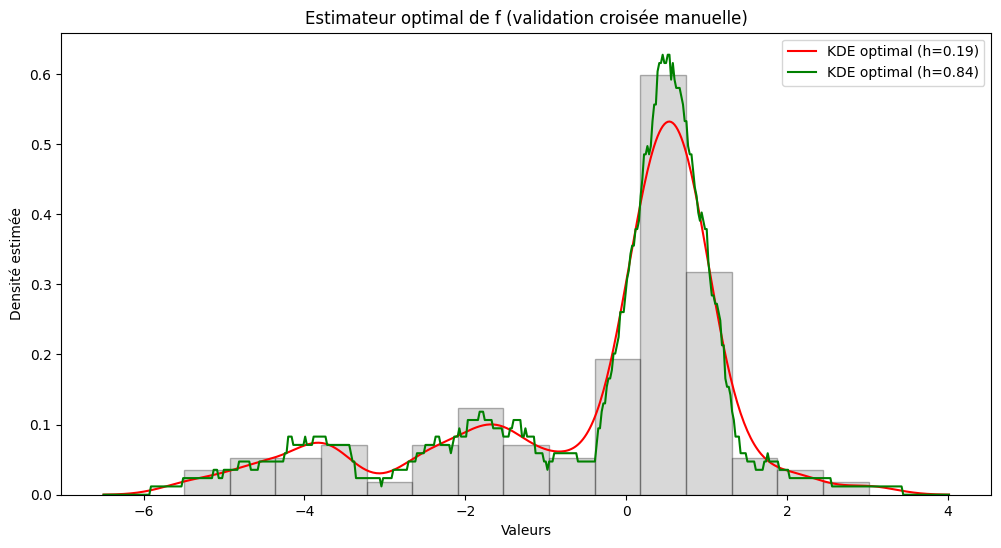

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(x_eval, dens_optimal, color="red", label=f"KDE optimal (h={best_bw:.2f})")
plt.plot(x_eval, dens_optimal1, color="green", label=f"KDE optimal (h={best_bw1:.2f})")
plt.hist(X, bins=15, density=True, alpha=0.3, color='grey', edgecolor='black')
plt.title("Estimateur optimal de f (validation croisée manuelle)")
plt.xlabel("Valeurs")
plt.ylabel("Densité estimée")
plt.legend()
plt.show()

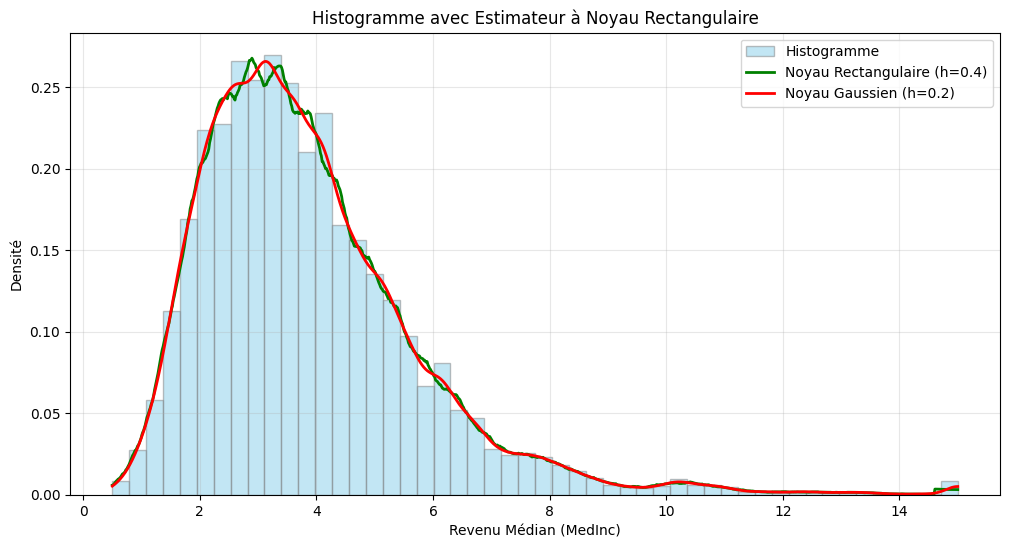

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [          -inf           -inf           -inf           -inf
           -inf           -inf           -inf           -inf
           -inf           -inf           -inf           -inf
           -inf           -inf           -inf           -inf
           -inf           -inf           -inf           -inf
           -inf           -inf -1913.88687605 -1913.98084173
 -1913.51199865 -1912.88562076 -1912.94943339 -1912.56489174
 -1912.87618266 -1913.84229461]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1119: RuntimeWarning: invalid value encountered in subtract
  (array - array_means[:, np.newaxis]) ** 2, axis=1, weights=weights


Meilleure bande passante trouvée (Gaussien) : 0.097
Meilleure bande passante trouvée (Rectangulaire) : 0.469


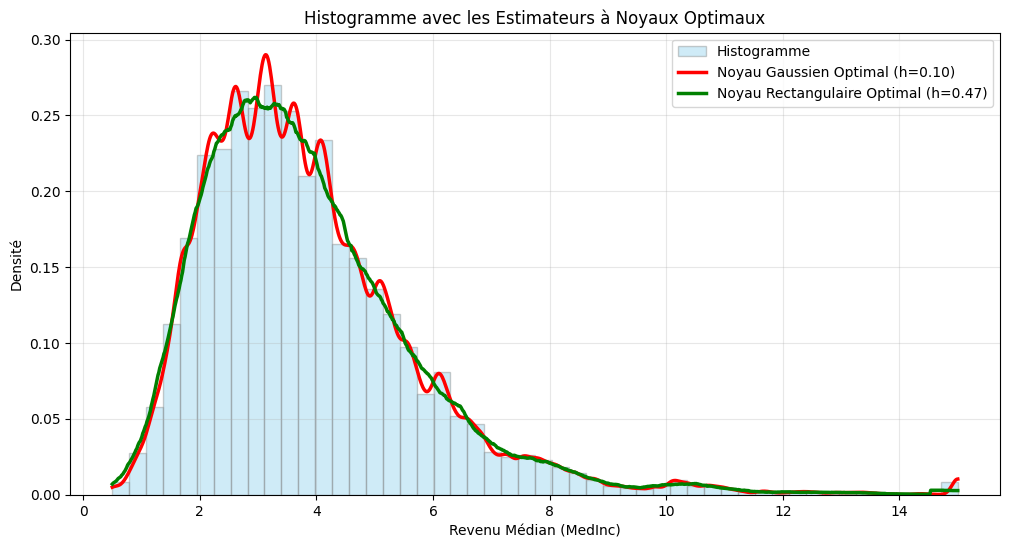

In [ ]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV, train_test_split

# --- 1. CHARGEMENT ET PRÉPARATION DES DONNÉES ---
housing = fetch_california_housing()
# On prend le revenu médian et on le met en format colonne
X_full = housing.data[:, 0].reshape(-1, 1)

# On crée un espace de points pour tracer les courbes de densité
x_eval = np.linspace(X_full.min(), X_full.max(), 1000).reshape(-1, 1)

# --- 2. GRAPHIQUE 1 : HISTOGRAMME + NOYAU RECTANGULAIRE (AVEC h FIXE) ---
# On choisit une bande passante "au hasard" pour l'exemple
kde_rect = KernelDensity(kernel='tophat', bandwidth=0.4).fit(X_full)
kde_gauss = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(X_full)
log_dens_rect = kde_rect.score_samples(x_eval)
log_dens_gauss = kde_gauss.score_samples(x_eval)

plt.figure(figsize=(12, 6))
plt.hist(X_full, bins=50, density=True, alpha=0.5, color='skyblue', edgecolor='grey', label='Histogramme')
plt.plot(x_eval, np.exp(log_dens_rect), color='green', lw=2, label='Noyau Rectangulaire (h=0.4)')
plt.plot(x_eval, np.exp(log_dens_gauss), color='red', lw=2, label='Noyau Gaussien (h=0.2)')
plt.title('Histogramme avec Estimateur à Noyau Rectangulaire')
plt.xlabel('Revenu Médian (MedInc)')
plt.ylabel('Densité')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# --- 4. TROUVER LA BANDE PASSANTE OPTIMALE POUR LE DERNIER GRAPHIQUE ---
# Pour accélérer, on cherche sur un échantillon de 5000 points
X_sample, _ = train_test_split(X_full, train_size=5000, random_state=42)
bandwidths = {'bandwidth': np.linspace(0.05, 0.5, 30)}

# Recherche pour le noyau Gaussien
grid_gauss_opt = GridSearchCV(KernelDensity(kernel='gaussian'), param_grid=bandwidths, cv=5)
grid_gauss_opt.fit(X_sample)
best_bw_gauss = grid_gauss_opt.best_params_['bandwidth']

# Recherche pour le noyau Rectangulaire (tophat)
grid_tophat_opt = GridSearchCV(KernelDensity(kernel='tophat'), param_grid=bandwidths, cv=5)
grid_tophat_opt.fit(X_sample)
best_bw_tophat = grid_tophat_opt.best_params_['bandwidth']

print(f"Meilleure bande passante trouvée (Gaussien) : {best_bw_gauss:.3f}")
print(f"Meilleure bande passante trouvée (Rectangulaire) : {best_bw_tophat:.3f}")


# --- 5. GRAPHIQUE 3 : HISTOGRAMME + NOYAUX OPTIMAUX ---
# On applique les meilleures bandes passantes trouvées
kde_gauss_opt = KernelDensity(kernel='gaussian', bandwidth=best_bw_gauss).fit(X_full)
kde_rect_opt = KernelDensity(kernel='tophat', bandwidth=best_bw_tophat).fit(X_full)

log_dens_gauss_opt = kde_gauss_opt.score_samples(x_eval)
log_dens_rect_opt = kde_rect_opt.score_samples(x_eval)

plt.figure(figsize=(12, 6))
plt.hist(X_full, bins=50, density=True, alpha=0.4, color='skyblue', edgecolor='grey', label='Histogramme')
plt.plot(x_eval, np.exp(log_dens_gauss_opt), color='red', lw=2.5, linestyle='-', label=f'Noyau Gaussien Optimal (h={best_bw_gauss:.2f})')
plt.plot(x_eval, np.exp(log_dens_rect_opt), color='green', lw=2.5, linestyle='-', label=f'Noyau Rectangulaire Optimal (h={best_bw_tophat:.2f})')
plt.title('Histogramme avec les Estimateurs à Noyaux Optimaux')
plt.xlabel('Revenu Médian (MedInc)')
plt.ylabel('Densité')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()